In [1]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS/CLI-Demos
/home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [2]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['mp4', 'custom_dicom', 'nifti', 'avi']


In [3]:
scan_type = 'nifti'

# Takes the DICOM file as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P07-V02-CE01/HighQuality/UCSD-P07-V02-CE01RUN2_09.39.44/UCSD-P07-V02-CE01RUN2_09.39.44_mf_sip_capture_50_2_1_0_CEUS.nii'
bmode_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P07-V02-CE01/HighQuality/UCSD-P07-V02-CE01RUN2_09.39.44/UCSD-P07-V02-CE01RUN2_09.39.44_mf_sip_capture_50_2_1_0_BMODE.nii'
scan_loader_kwargs = {
}

In [4]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, CEUS_scan_path, **scan_loader_kwargs)
bmode_image_data = scan_loading_step(scan_type, bmode_scan_path, **scan_loader_kwargs)

## Load Segmentation with correct Motion compensation

Assumes same segmentation for each frame

In [5]:
import pickle
with open('/home/yuanshanwu/Documents/TUL/CEUS-Studies/P07-V02-CE01/HighQuality/seg_data_with_mc_correlation_based.pkl', 'rb') as f:
    seg_data = pickle.load(f)

In [6]:
from src.time_series_analysis.options import get_analysis_types, get_required_kwargs

all_analysis_types, all_analysis_funcs = get_analysis_types()
print("Available analysis types:", list(all_analysis_types.keys()))

Available analysis types: ['curves', 'curves_paramap']


In [7]:
analysis_type = 'curves'

print("Available analysis functions:", list(all_analysis_funcs.keys()))

Available analysis functions: ['pyradiomics', 'tic']


In [8]:
analysis_funcs = ['tic']

# Find all required kwargs for the analysis functions
analysis_funcs = analysis_funcs if len(analysis_funcs) else list(all_analysis_funcs[analysis_type].keys())
required_kwargs = get_required_kwargs(analysis_type, analysis_funcs)
print("Required kwargs for current analysis:", required_kwargs)

Required kwargs for current analysis: []


In [11]:
analysis_kwargs = {
    # 'pyradiomics_config_paths': [
    #     '/home/das/QuantUS_Projs/QuantUS-Plugins-CEUS/configs/pyradiomics/moderate-pselectin.yml',
    # ],
    # 'curves_output_path': 'test2.csv',
    # 'binwidth': 25,
    # 'min_intensity': 0,
}

In [12]:
from src.entrypoints import analysis_step

analysis_obj = analysis_step(analysis_type, image_data, seg_data, analysis_funcs, **analysis_kwargs)

Computing curves: 100%|██████████| 530/530 [00:14<00:00, 37.53it/s]


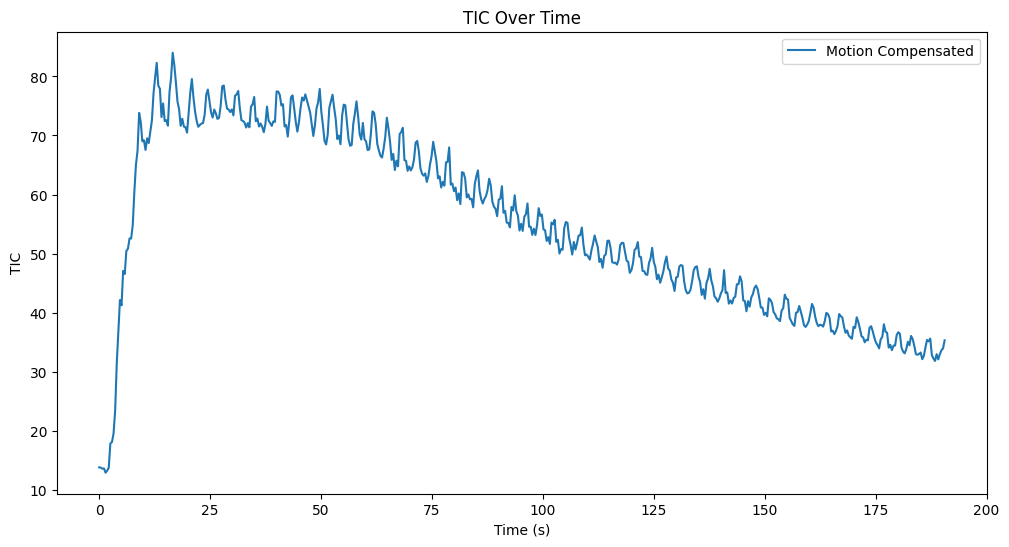

In [13]:
import matplotlib.pyplot as plt

# Create a figure with a specific size (e.g., 8 inches wide, 6 inches tall)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(analysis_obj.time_arr,analysis_obj.curves[0]['TIC'], label='Motion Compensated')

ax.set_xlabel('Time (s)')
ax.set_ylabel('TIC')
ax.set_title('TIC Over Time')
ax.legend()

plt.show()

In [14]:
from src.curve_quantification.options import get_quantification_funcs

quantification_funcs = get_quantification_funcs()
print("Available quantification functions:", quantification_funcs.keys())

Available quantification functions: dict_keys(['auc_no_fit', 'cmus_firstorder', 'dte', 'first_order_full', 'first_order_select', 'lognormal_fit_full', 'lognormal_fit_select', 'wash_rates'])


In [15]:
function_names = ['lognormal_fit_full'] # Empty list will use all functions
output_path = 'test_quants.csv'
curve_quantifications_kwargs = {
    'curves_to_fit': ['TIC'],
}
print("Required kwargs for preprocessing functions:", required_kwargs)

Required kwargs for preprocessing functions: []


In [16]:
from src.entrypoints import curve_quantification_step

curve_quant = curve_quantification_step(analysis_obj, function_names, output_path, **curve_quantifications_kwargs)